In [1]:
import pandas as pd
import pickle
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from scipy.stats import chi2
import textwrap

# Dependency
* DGIDB_hypergraph
* Clustering_Result_Analysis

# Loading Variables

In [2]:
DISEASE = input("Disease: ")
DISEASE_FOLDER = f"../output/{DISEASE}/"
DGIDB_DIRECTORY = f"../../Gen_Hypergraph/output/DGIDB_{DISEASE}/"

# Comm DGIDB genes count

In [4]:
def DGIDB_count(c,DGIDB_genes_ncbi):
    return set(c) & set(DGIDB_genes_ncbi)

In [5]:
with open(f"{DISEASE_FOLDER}/result_communities_ncbi_selected.pkl", "rb") as f:
    communities_ncbi_selected = pickle.load(f)
with open(f"{DISEASE_FOLDER}/result_communities_ncbi.pkl", "rb") as f:
    communities_ncbi = pickle.load(f)
with open(DGIDB_DIRECTORY + f"gene_to_index.json", "r") as file:
    DGIDB_gene_to_index = json.load(file)
DGIDB_genes = set(DGIDB_gene_to_index.keys())

In [6]:
comm_dgidb_gene_count = {}
for i in range(len(communities_ncbi_selected)):
    dgidb_genes_set = DGIDB_count(communities_ncbi[i],DGIDB_genes)
    print(i,len(dgidb_genes_set), dgidb_genes_set)
    print(len(communities_ncbi[i]))
    comm_dgidb_gene_count[i] = len(dgidb_genes_set)
    
with open(f"../output/{DISEASE}/comm_dgidb_gene_count.json","w") as f:
    json.dump(comm_dgidb_gene_count,f)    

0 0 set()
3256
1 86 {'2740', '7172', '151', '3357', '1816', '22999', '2326', '259232', '3359', '10919', '3354', '1814', '3269', '5999', '1', '3351', '3', '1002', '5325', '152', '3778', '1812', '215', '152330', '1103', '440275', '1815', '5468', '26298', '1129', '928', '11', '4160', '100302251', '7957', '1813', '3757', '1139', '196', '3362', '2671', '150', '9135', '2641', '3358', '155', '23216', '3363', '693167', '1132', '267012', '2947', '6580', '1131', '3350', '885', '2', '3352', '5144', '887', '64478', '2166', '2696', '153', '5565', '319100', '148', '6505', '1133', '2328', '2548', '477', '3356', '2784', '5799', '4067', '12', '100302144', '2950', '339745', '1128', '147', '262', '115019', '255239', '3552'}
2905
2 0 set()
2836
3 1 {'926'}
2670
4 56 {'1636', '4524', '54659', '6532', '22908', '6571', '54578', '64816', '6530', '54658', '216', '2678', '79718', '1621', '1559', '8856', '54577', '54575', '1548', '5311', '54576', '1562', '1571', '22854', '170680', '1565', '10', '348', '2587', '4

# important terms processing

In [7]:
with open(f"{DISEASE_FOLDER}/result_communities_selected.pkl", "rb") as f:
    communities_selected = pickle.load(f)

In [8]:
important_terms = pd.read_csv(DISEASE_FOLDER + "important_terms.csv")

In [9]:
important_terms = important_terms.sort_values(
    by=["Community Index", "Adjusted P-value"],
    ascending=[True, True]
).reset_index(drop=True)

In [10]:
important_terms

,Community Index,Community Size,Term,Overlap,Adjusted P-value,Category,Gene_set,P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Overlap (value)
0,0,1120,Antigen Processing: Ubiquitination And Proteas...,86/307,1.312370e-34,['Immune System'],Reactome_2022,4.621019e-37,0.0,0.0,7.022213,587.513690,UBE2D4;RNF14;LTN1;UBE3A;UBE3B;FBXO21;HERC4;NPE...,0.280130
1,0,1120,Class I MHC Mediated Antigen Processing And Pr...,86/378,1.315687e-27,['Immune System'],Reactome_2022,9.265402e-30,0.0,0.0,5.294534,353.946285,UBE2D4;RNF14;LTN1;UBE3A;UBE3B;FBXO21;HERC4;NPE...,0.227513
2,0,1120,Neddylation R-HSA-8951664,61/237,1.948360e-22,['Metabolism of proteins'],Reactome_2022,2.058127e-24,0.0,0.0,6.121470,333.866461,DCAF8;DCAF5;FBXO21;DCAF4;DCAF6;DDA1;NUB1;UBXN7...,0.257384
3,0,1120,Ubiquitin-Protein Transferase Activity (GO:000...,80/412,2.129653e-20,['catalytic activity'],GO_Molecular_Function_2023,5.634003e-23,0.0,0.0,4.297498,220.163544,RNF10;UBE2D4;RNF13;PPP1R11;RNF14;LTN1;UBE3A;UB...,0.194175
4,0,1120,cullin-RING Ubiquitin Ligase Complex (GO:0031461),46/174,6.459549e-17,['protein-containing complex'],GO_Cellular_Component_2023,3.166446e-19,0.0,0.0,6.274674,267.279200,CUL9;CUL7;TMEM183A;PEF1;PDCD6;DCAF8;KLHL13;DCA...,0.264368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1908,11,217,Olfactory Receptor Activity (GO:0004984),174/362,1.574092e-279,['molecular transducer activity'],GO_Molecular_Function_2023,5.246974e-280,0.0,0.0,421.762741,271221.352567,OR1C1;OR5K4;OR52N1;OR2M5;OR2M4;OR2T12;OR2T10;O...,0.480663
1909,11,217,Sensory Perception Of Smell (GO:0007608),112/230,6.660332e-167,['multicellular organismal process'],GO_Biological_Process_2023,2.220111e-168,0.0,0.0,177.762712,68622.937530,OR1C1;OR2M5;OR2M4;OR2T12;OR2T10;OR10AC1;OR2T11...,0.486957
1910,11,217,Detection Of Chemical Stimulus Involved In Sen...,69/141,2.527752e-99,['response to stimulus'],GO_Biological_Process_2023,1.685168e-100,0.0,0.0,127.633164,29322.014847,OR10J1;OR2A1;OR4E2;OR10J3;OR4E1;OR10J5;OR13H1;...,0.489362
1911,11,217,Detection Of Chemical Stimulus Involved In Sen...,68/139,5.700298e-98,['response to stimulus'],GO_Biological_Process_2023,5.700298e-99,0.0,0.0,126.705360,28662.704343,OR10J1;OR2A1;OR4E2;OR10J3;OR4E1;OR10J5;OR13H1;...,0.489209


# Community Category df

In [11]:
df = important_terms

# ---------------------------------------------------
# 1. Parse Category column (stringified list) -> list
# ---------------------------------------------------
df["Category"] = df["Category"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# ---------------------------------------------------
# 2. Explode: one category per row
# ---------------------------------------------------
df_exp = df.explode("Category").reset_index(drop=True)

# ---------------------------------------------------
# 3. Parse Overlap "a/b" into numerator and denominator
# ---------------------------------------------------
def parse_overlap(s):
    try:
        a, b = s.split("/")
        return int(a), int(b)
    except Exception:
        return 0, 0

overlap_nums = []
overlap_dens = []

for s in df_exp["Overlap"]:
    a, b = parse_overlap(s)
    overlap_nums.append(a)
    overlap_dens.append(b)

df_exp["Overlap_num"] = overlap_nums
df_exp["Overlap_den"] = overlap_dens

# ---------------------------------------------------
# 4. Total number of terms per community
# ---------------------------------------------------
total_terms = (
    df_exp.groupby("Community Index")["Term"]
          .nunique()
)

# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
# ---------------------------------------------------
# ---------------------------------------------------
# 5. Aggregate per (Community Index, Category)
#    - count = # of distinct terms
#    - Gross Overlap = (sum a_i) / (sum b_i)
#    - fisher_p = Fisher-combined p-value over terms in that category
# ---------------------------------------------------
def fisher_method(pvals):
    p = pd.Series(pvals).dropna().astype(float)
    if len(p) == 0:
        return np.nan

    # avoid log(0)
    p = p.clip(lower=1e-300)

    stat = -2.0 * np.sum(np.log(p))
    df = 2 * len(p)
    return float(chi2.sf(stat, df))

agg = (
    df_exp.groupby(["Community Index", "Category"])
    .agg(
        count=("Term", "nunique"),
        sum_a=("Overlap_num", "sum"),
        sum_b=("Overlap_den", "sum"),
        fisher_p=("Adjusted P-value", fisher_method),  # <-- change column name if needed
    )
    .reset_index()
)

agg["Gross Overlap"] = agg["sum_a"] / agg["sum_b"]

# ---------------------------------------------------
# 6. Add total_terms_in_comm and frac_of_comm
# ---------------------------------------------------
agg["total_terms_in_comm"] = agg["Community Index"].map(total_terms)
agg["frac_of_comm"] = agg["count"] / agg["total_terms_in_comm"]

# ---------------------------------------------------
# 7. Final output df
# ---------------------------------------------------
community_categories = agg[[
    "Community Index",
    "Category",
    "count",
    "Gross Overlap",
    "fisher_p",
    "total_terms_in_comm",
    "frac_of_comm",
]]


community_categories = community_categories.sort_values(
    by=["Community Index", "count"],
    ascending=[True, False]
).reset_index(drop=True)

community_categories


,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm
0,0,catalytic activity,6,0.196919,5.216571e-64,18,0.333333
1,0,cellular process,6,0.174553,3.033093e-56,18,0.333333
2,0,Immune System,3,0.182652,3.535707e-66,18,0.166667
3,0,Metabolism of proteins,1,0.257384,1.948360e-22,18,0.055556
4,0,molecular adaptor activity,1,0.363636,5.987088e-08,18,0.055556
...,...,...,...,...,...,...,...
211,11,Sensory Perception,3,0.434043,0.000000e+00,9,0.333333
212,11,multicellular organismal process,2,0.485294,1.241653e-238,9,0.222222
213,11,response to stimulus,2,0.489286,6.511998e-194,9,0.222222
214,11,Sensory system,1,0.477273,1.000000e-300,9,0.111111


In [12]:
community_categories["fisher_score"] = -np.log10(
    community_categories["fisher_p"].clip(lower=1e-300)
)

mn = community_categories["fisher_score"].min()
mx = community_categories["fisher_score"].max()

community_categories["fisher_norm"] = (community_categories["fisher_score"] - mn) / (mx - mn)

def safe_z(x):
    mu = x.mean()
    sd = x.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return pd.Series(0.0, index=x.index)   # or return x*0
    return (x - mu) / sd

community_categories["fisher_z"] = (
    community_categories
    .groupby("Community Index")["fisher_score"]
    .transform(safe_z)
)




In [13]:
community_categories

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,catalytic activity,6,0.196919,5.216571e-64,18,0.333333,63.282615,0.197490,1.054372
1,0,cellular process,6,0.174553,3.033093e-56,18,0.333333,55.518114,0.171167,0.727604
2,0,Immune System,3,0.182652,3.535707e-66,18,0.166667,65.451524,0.204843,1.145651
3,0,Metabolism of proteins,1,0.257384,1.948360e-22,18,0.055556,21.710331,0.056553,-0.695196
4,0,molecular adaptor activity,1,0.363636,5.987088e-08,18,0.055556,7.222784,0.007438,-1.304904
...,...,...,...,...,...,...,...,...,...,...
211,11,Sensory Perception,3,0.434043,0.000000e+00,9,0.333333,300.000000,1.000000,0.922894
212,11,multicellular organismal process,2,0.485294,1.241653e-238,9,0.222222,237.906000,0.789491,-0.584332
213,11,response to stimulus,2,0.489286,6.511998e-194,9,0.222222,193.186286,0.637884,-1.669827
214,11,Sensory system,1,0.477273,1.000000e-300,9,0.111111,300.000000,1.000000,0.922894


## filtering top 5 categories

In [14]:
# community_categories_filtered = (
#     community_categories.sort_values(["Community Index", "count"], ascending=[True, False])
#           .groupby("Community Index")
#           .head(5)
#           .reset_index(drop=True)
# )

In [15]:
# community_categories_filtered

In [16]:
# from reportlab.lib.pagesizes import letter, landscape
# from reportlab.platypus import SimpleDocTemplate, Table, TableStyle
# from reportlab.lib import colors

# def df_to_pdf(df, filename="output.pdf"):
#     pdf = SimpleDocTemplate(
#         filename,
#         pagesize=landscape(letter)
#     )

#     # Convert DF to 2D list
#     data = [df.columns.tolist()] + df.values.tolist()

#     # Create table
#     table = Table(data)

#     # Styling
#     style = TableStyle([
#         ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
#         ("TEXTCOLOR", (0,0), (-1,0), colors.black),
#         ("ALIGN", (0,0), (-1,-1), "CENTER"),
#         ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
#         ("FONTSIZE", (0,0), (-1,-1), 8),
#         ("BOTTOMPADDING", (0,0), (-1,0), 8),
#         ("GRID", (0,0), (-1,-1), 0.25, colors.black),
#     ])
#     table.setStyle(style)

#     elements = [table]
#     pdf.build(elements)
#     print(f"PDF saved to {filename}")


## output to pdf

In [17]:
# community_categories_filtered

In [18]:
# df_to_pdf(community_categories_filtered, f"../../Graphs/{DISEASE}/community_categories_filtered.pdf")

# Community Count Dict

In [19]:
category_count_by_comm = {}

for _, row in community_categories.iterrows():
    comm = row["Community Index"]
    cat = row["Category"]
    count = row["count"]
    gross = row["Gross Overlap"]

    if comm not in category_count_by_comm:
        category_count_by_comm[comm] = {}

    # insertion happens in sorted order because community_categories is sorted
    category_count_by_comm[comm][cat] = (count, gross)


In [20]:
for i in range(len(communities_selected)):
    if i not in category_count_by_comm.keys():
        category_count_by_comm[i] = {}

In [21]:
category_count_by_comm

{0: {'catalytic activity': (6, 0.19691895512391158),
  'cellular process': (6, 0.17455310199789695),
  'Immune System': (3, 0.18265162200282087),
  'Metabolism of proteins': (1, 0.25738396624472576),
  'molecular adaptor activity': (1, 0.36363636363636365),
  'protein-containing complex': (1, 0.26436781609195403)},
 1: {'Signal Transduction': (13, 0.23824855119124275),
  'binding': (13, 0.21147356580427445),
  'biological regulation': (11, 0.13692242475625266),
  'cellular process': (11, 0.2540929927963327),
  'developmental process': (7, 0.204149377593361),
  'transporter activity': (4, 0.34220532319391633),
  'Disease': (3, 0.2154696132596685),
  'molecular function regulator activity': (3, 0.3253968253968254),
  'molecular transducer activity': (3, 0.39118457300275483),
  'Neuronal System': (2, 0.3793103448275862),
  'localization': (2, 0.25868725868725867),
  'protein-containing complex': (2, 0.38311688311688313),
  'Signaling molecules and interaction': (1, 0.30791788856304986),
 

In [22]:
with open(f"{DISEASE_FOLDER}/category_count_by_comm.pkl", "wb") as f:
    pickle.dump(category_count_by_comm, f)

# Heatmap with filtered categories

In [23]:
# counts = important_terms["Community Index"].value_counts()
# top_idx = counts.idxmax()
# top_idx

In [24]:
# adj = pd.to_numeric(important_terms["Adjusted P-value"], errors="coerce")
# zero_indices = important_terms.loc[adj == 0, "Community Index"].unique()
# olf_idx = int(zero_indices[0]) if len(zero_indices) > 0 else None
# olf_idx

In [25]:
# list of index of top 5 highest DGIDB gene count
if DISEASE != "NONE":
    sorted_comm = sorted(comm_dgidb_gene_count.items(), key=lambda x: x[1], reverse=True)
    top_5_comm_indices = [idx for idx, count in sorted_comm[:5]]
else:
    top_5_comm_indices = important_terms["Community Index"].unique().tolist()


In [26]:
top_5_comm_indices

[1, 5, 7, 4, 11]

In [27]:
#################
################
top_5_comm_indices = important_terms["Community Index"].unique().tolist()

In [28]:
top_5_comm_indices

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [29]:
# # idx = [k for k in range(len(important_terms["Community Index"].unique())) if k != top_idx and k != olf_idx]
# idx = [k for k in range(len(important_terms["Community Index"].unique()))]

In [30]:
with open(f"{DISEASE_FOLDER}/important_comm_idx.pkl", "wb") as f:
    pickle.dump(top_5_comm_indices, f)

In [31]:
community_categories_filtered = community_categories[community_categories["Community Index"].isin(top_5_comm_indices)]

In [32]:
community_categories_filtered

,Community Index,Category,count,Gross Overlap,fisher_p,total_terms_in_comm,frac_of_comm,fisher_score,fisher_norm,fisher_z
0,0,catalytic activity,6,0.196919,5.216571e-64,18,0.333333,63.282615,0.197490,1.054372
1,0,cellular process,6,0.174553,3.033093e-56,18,0.333333,55.518114,0.171167,0.727604
2,0,Immune System,3,0.182652,3.535707e-66,18,0.166667,65.451524,0.204843,1.145651
3,0,Metabolism of proteins,1,0.257384,1.948360e-22,18,0.055556,21.710331,0.056553,-0.695196
4,0,molecular adaptor activity,1,0.363636,5.987088e-08,18,0.055556,7.222784,0.007438,-1.304904
...,...,...,...,...,...,...,...,...,...,...
211,11,Sensory Perception,3,0.434043,0.000000e+00,9,0.333333,300.000000,1.000000,0.922894
212,11,multicellular organismal process,2,0.485294,1.241653e-238,9,0.222222,237.906000,0.789491,-0.584332
213,11,response to stimulus,2,0.489286,6.511998e-194,9,0.222222,193.186286,0.637884,-1.669827
214,11,Sensory system,1,0.477273,1.000000e-300,9,0.111111,300.000000,1.000000,0.922894


In [33]:
font_size = 13
tick_font_size = 13
plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": font_size,
    "axes.labelsize": font_size,
    "xtick.labelsize": tick_font_size,
    "ytick.labelsize": tick_font_size,
    "legend.fontsize": font_size,
    "figure.titlesize": font_size,
    "legend.loc": 'best'
})


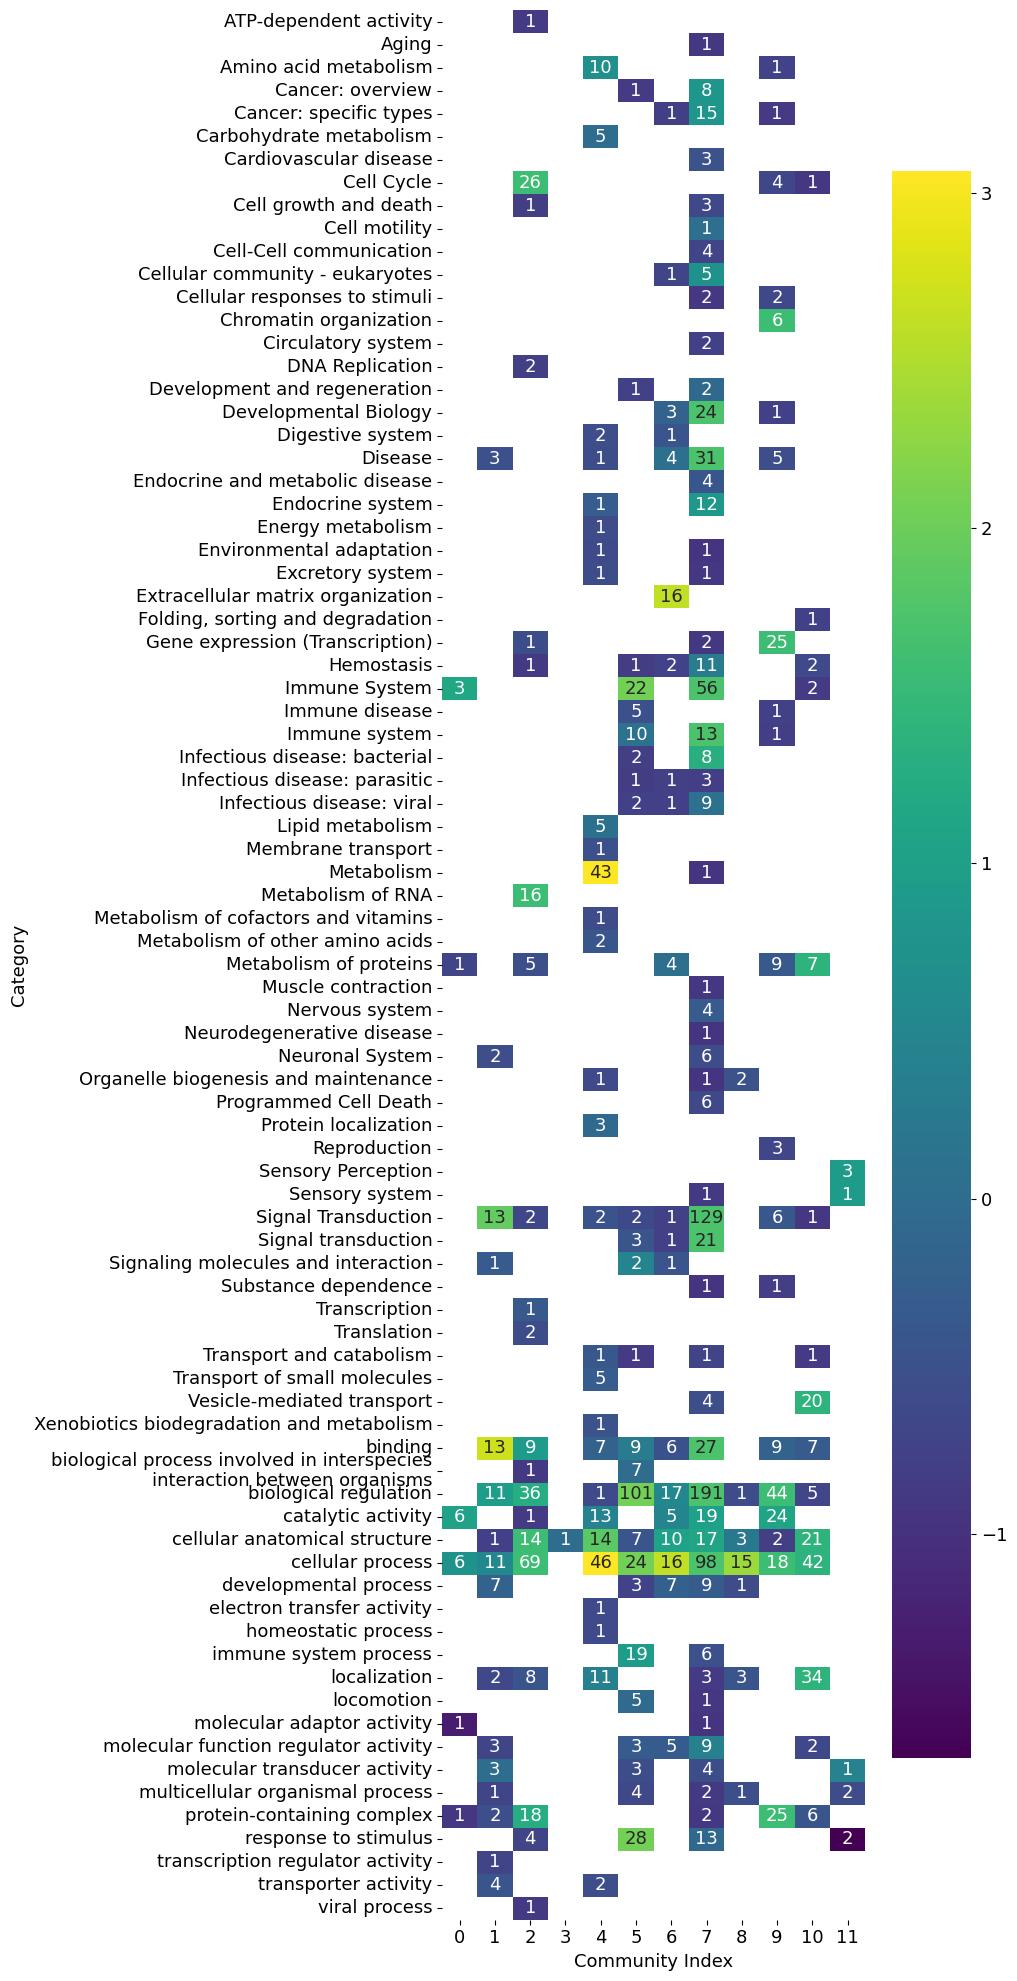

In [34]:
heat_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="fisher_z"
).reindex(columns = top_5_comm_indices)

label_df = community_categories_filtered.pivot(
    index="Category",
    columns="Community Index",
    values="count"
).reindex(columns = top_5_comm_indices)
plt.figure(figsize=(10,20))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    annot=label_df,   # <-- use count for labels
    fmt=".0f",        # integer labels
    cbar=True
)

# ---- WRAP Y-AXIS LABELS ----
MAX_CHARS = 50  # tweak this
wrapped = ["\n".join(textwrap.wrap(str(s), width=MAX_CHARS)) for s in heat_df.index]
ax.set_yticklabels(wrapped, rotation=0)  # keep horizontal

plt.tight_layout()
plt.savefig(f"../../Graphs/{DISEASE}/category_gross_overlap_heatmap.png", bbox_inches="tight")
plt.show()
